# Hotel Booking Analytics

## Exploratory Data Analysis of Booking and Cancellation Behaviour

### Introduction

This project analyzes hotel booking data to understand customer
booking and cancellation behaviour.

The dataset contains hotel booking records from 2017 to 2019.
The analysis focuses on three main business questions:

1. Which hotel type do customers book most often?
2. Does the length of stay affect the booking cancellation rate?
3. Does lead time affect the booking cancellation rate?

The analysis includes data cleaning, exploratory data analysis,
visualization, insights and business recommendations.

### Objective

The main objective is to identify useful patterns in hotel bookings
and cancellations and convert these findings into actionable
recommendations for hotel business management.

## 1. Importing Required Libraries

The following Python libraries are used for data manipulation,
numerical operations and data visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2. Loading the Dataset

The hotel booking dataset is loaded into a Pandas DataFrame for
further analysis.

In [3]:
df = pd.read_csv('hotel_bookings_data.csv')

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,2017,September,27,1,0,0,2,...,3,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
1,Resort Hotel,0,737,2017,September,27,1,0,0,2,...,4,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
2,Resort Hotel,0,7,2017,September,27,1,0,1,1,...,0,No Deposit,NaN,NaN,0,Personal,75.0,0,0,Check-Out
3,Resort Hotel,0,13,2017,September,27,1,0,1,1,...,0,No Deposit,304.0,NaN,0,Personal,75.0,0,0,Check-Out
4,Resort Hotel,0,14,2017,September,27,1,0,2,2,...,0,No Deposit,240.0,NaN,0,Personal,98.0,0,1,Check-Out


## 3. Dataset Overview

Before performing analysis, the dataset is examined to understand
its size, structure, column names and data types.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 119390
Number of columns: 29


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2018.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2018.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2018.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2019.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2019.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## 4. Missing Value Analysis

Missing values can affect the accuracy of analysis. Therefore,
the dataset is checked for missing values before proceeding
with further analysis.

In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

company     112593
agent        16340
city           488
children         4
dtype: int64

In [9]:
df['children'] = df['children'].fillna(0)
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)
df['city'] = df['city'].fillna('Unknown')

## 5. Duplicate Value Analysis

Duplicate records can lead to incorrect booking counts and
misleading analysis. Therefore, duplicate rows are identified
and removed.

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 33261


In [11]:
df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())

Duplicates after removal: 0


## 6. Handling Inconsistent Values

The meal column contains an 'Undefined' category. Since this
represents bookings where a specific meal plan was not recorded,
it is grouped with the Self Catering category for analysis.

In [12]:
df['meal'].value_counts()

meal
Breakfast     67088
No Meal        9442
Dinner         8798
Undefined       454
Full Board      347
Name: count, dtype: int64

In [13]:
df['meal'] = df['meal'].replace('Undefined', 'SC')

## 7. Handling Anomalies

The dataset is checked for unrealistic records such as negative
Average Daily Rate (ADR) values and bookings where no guests
were recorded.

Such records can distort business analysis and are therefore
removed.

In [14]:
df[df['adr'] < 0][['adr']]

,adr
14969,-6.38


In [15]:
df = df[df['adr'] >= 0]

In [16]:
df['total_guests'] = (
    df['adults'] +
    df['children'] +
    df['babies']
)

In [17]:
df[df['total_guests'] == 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,total_guests
2224,Resort Hotel,0,1,2017,December,41,6,0,3,0,...,No Deposit,0.0,174.0,0,Family,0.00,0,0,Check-Out,0.0
2409,Resort Hotel,0,0,2017,December,42,12,0,0,0,...,No Deposit,0.0,174.0,0,Personal,0.00,0,0,Check-Out,0.0
3181,Resort Hotel,0,36,2017,January,47,20,1,2,0,...,No Deposit,38.0,0.0,0,Family,0.00,0,0,Check-Out,0.0
3684,Resort Hotel,0,165,2017,February,53,30,1,4,0,...,No Deposit,308.0,0.0,122,Family,0.00,0,0,Check-Out,0.0
3708,Resort Hotel,0,165,2017,February,53,30,2,4,0,...,No Deposit,308.0,0.0,122,Family,0.00,0,0,Check-Out,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2019,August,26,27,0,3,0,...,No Deposit,7.0,0.0,0,Personal,100.80,0,0,Check-Out,0.0
115091,City Hotel,0,1,2019,August,26,30,0,1,0,...,No Deposit,0.0,0.0,0,Personal,0.00,1,1,Check-Out,0.0
116251,City Hotel,0,44,2019,September,28,15,1,1,0,...,No Deposit,425.0,0.0,0,Personal,73.80,0,0,Check-Out,0.0
116534,City Hotel,0,2,2019,September,28,15,2,5,0,...,No Deposit,9.0,0.0,0,Family,22.86,0,1,Check-Out,0.0


In [18]:
df = df[df['total_guests'] > 0]

## 8. Feature Engineering

To analyze whether the length of stay affects cancellation,
a new feature called `total_stay` is created.

It represents the total number of nights spent at the hotel,
including both weekday and weekend nights.

In [19]:
df['total_stay'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_weekdays_nights']
)

df[['stays_in_weekend_nights',
   'stays_in_weekdays_nights',
   'total_stay']].head()

,stays_in_weekend_nights,stays_in_weekdays_nights,total_stay
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


## 9. Hotel Type Booking Distribution

The first analysis compares the number of bookings received by
City Hotel and Resort Hotel.

This helps identify which hotel type is more popular among
customers.

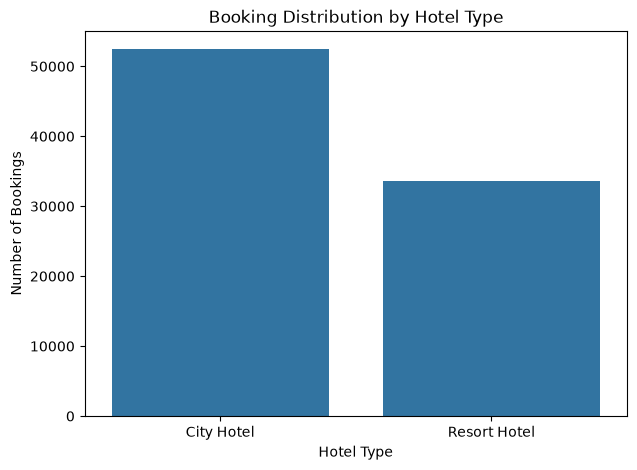

In [20]:
hotel_counts = df['hotel'].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=hotel_counts.index,
    y=hotel_counts.values
)

plt.title('Booking Distribution by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.show()

### Insight

The analysis shows that City Hotel receives more bookings than
Resort Hotel. This indicates that City Hotel has a larger share
of the bookings in the dataset.

Therefore, the hotel business should consider the higher demand
for City Hotel when planning room availability, staffing and
marketing strategies.

## 10. Monthly Booking Trend

Hotel demand can change throughout the year because of
seasonality, holidays, vacations and business travel.

This analysis examines the number of bookings received by
City Hotel and Resort Hotel during each month.

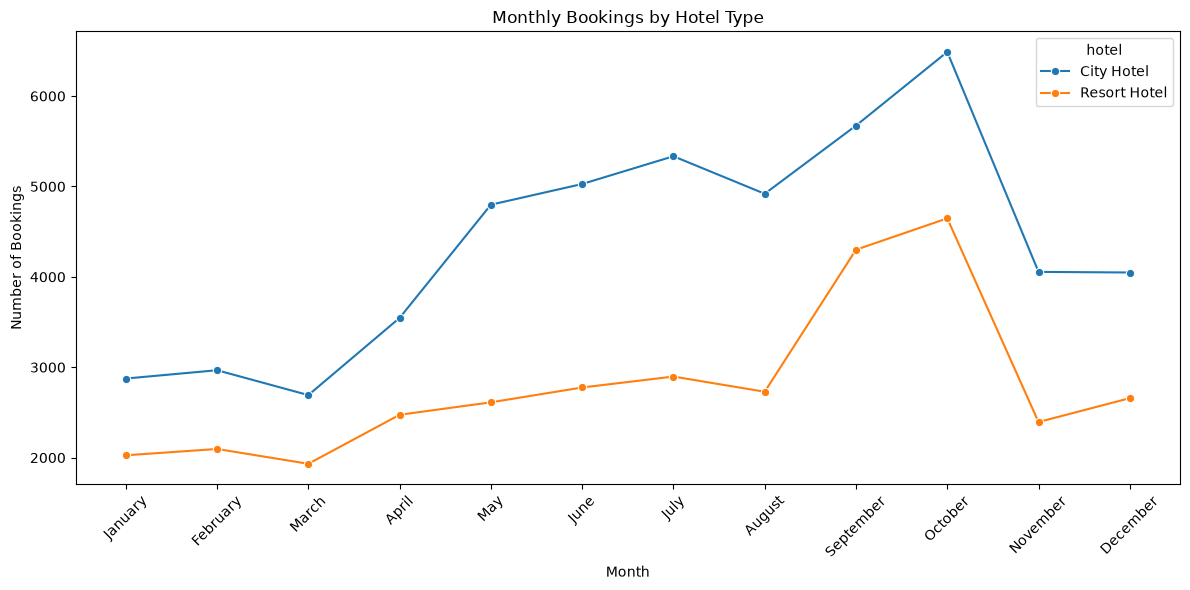

In [21]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_bookings = (
    df.groupby(['arrival_date_month', 'hotel'])
      .size()
      .reset_index(name='bookings')
)

monthly_bookings['arrival_date_month'] = pd.Categorical(
    monthly_bookings['arrival_date_month'],
    categories=month_order,
    ordered=True
)

monthly_bookings = monthly_bookings.sort_values(
    'arrival_date_month'
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_bookings,
    x='arrival_date_month',
    y='bookings',
    hue='hotel',
    marker='o'
)

plt.title('Monthly Bookings by Hotel Type')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Insight

The monthly booking trend shows that hotel demand changes
throughout the year rather than remaining constant.

Some months experience considerably higher booking volumes,
while other months have lower demand. This indicates a
seasonal pattern in hotel bookings.

The hotel can use this information to plan staffing,
room availability, pricing and promotional campaigns
according to expected demand.

## 11. Cancellation Rate by Hotel Type

The next analysis compares cancellation rates between City Hotel
and Resort Hotel.

Cancellation rate is calculated as the percentage of bookings
where `is_canceled` is equal to 1.

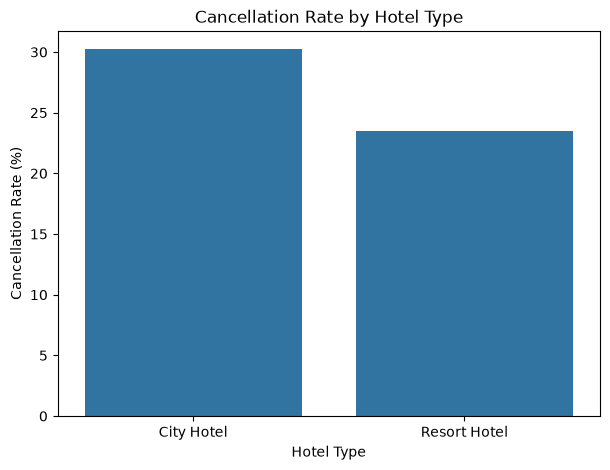

In [22]:
cancellation_by_hotel = (
    df.groupby('hotel')['is_canceled']
      .mean()
      .mul(100)
      .reset_index(name='cancellation_rate')
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=cancellation_by_hotel,
    x='hotel',
    y='cancellation_rate'
)

plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')

plt.show()

### Insight

The comparison shows that the cancellation rate is different
between the two hotel types.

City Hotel has a higher cancellation rate than Resort Hotel.
This indicates that City Hotel may face a greater risk of
revenue loss from cancelled bookings.

The hotel could therefore focus cancellation-reduction
strategies more strongly on City Hotel bookings.

## 12. Impact of Stay Duration on Cancellation Rate

The total length of stay is calculated using weekday and weekend
nights.

This analysis investigates whether longer stays are associated
with higher or lower cancellation rates for City Hotel and
Resort Hotel.

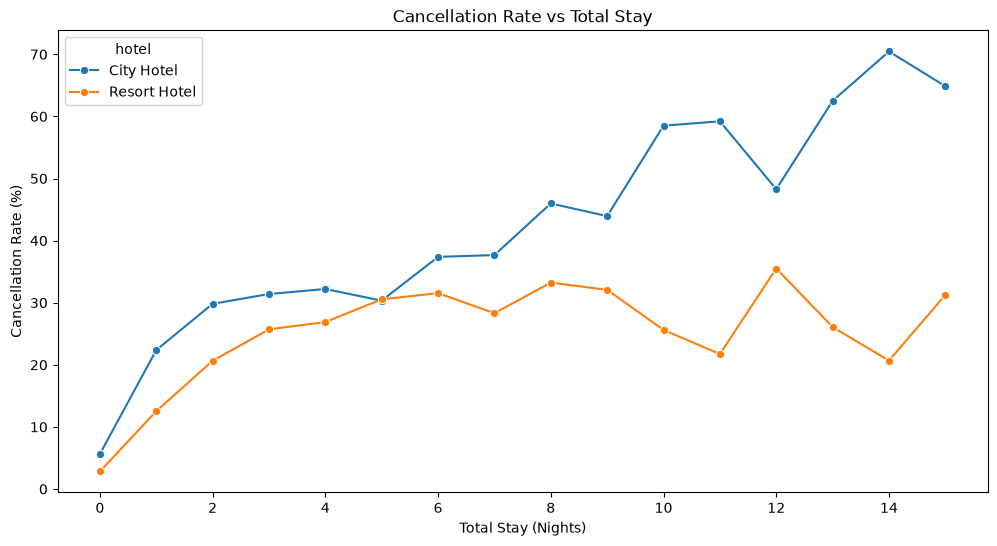

In [23]:
stay_cancellation = (
    df.groupby(['total_stay', 'hotel'])['is_canceled']
      .mean()
      .mul(100)
      .reset_index(name='cancellation_rate')
)

# Focus on stays up to 15 nights for clearer visualization
stay_cancellation_plot = stay_cancellation[
    stay_cancellation['total_stay'] <= 15
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=stay_cancellation_plot,
    x='total_stay',
    y='cancellation_rate',
    hue='hotel',
    marker='o'
)

plt.title('Cancellation Rate vs Total Stay')
plt.xlabel('Total Stay (Nights)')
plt.ylabel('Cancellation Rate (%)')

plt.show()

### Insight

The chart shows how cancellation rates change with the total
length of stay.

The relationship is not perfectly consistent for every stay
duration, but longer stays can show higher cancellation rates,
particularly for some hotel types.

This suggests that longer reservations may carry greater
cancellation risk and should be monitored when designing
cancellation policies and pricing strategies.

## 13. Impact of Lead Time on Cancellation Rate

Lead time refers to the number of days between the date a
booking is made and the guest's arrival date.

This analysis investigates whether bookings made further in
advance have a different cancellation risk compared with
bookings made closer to the arrival date.

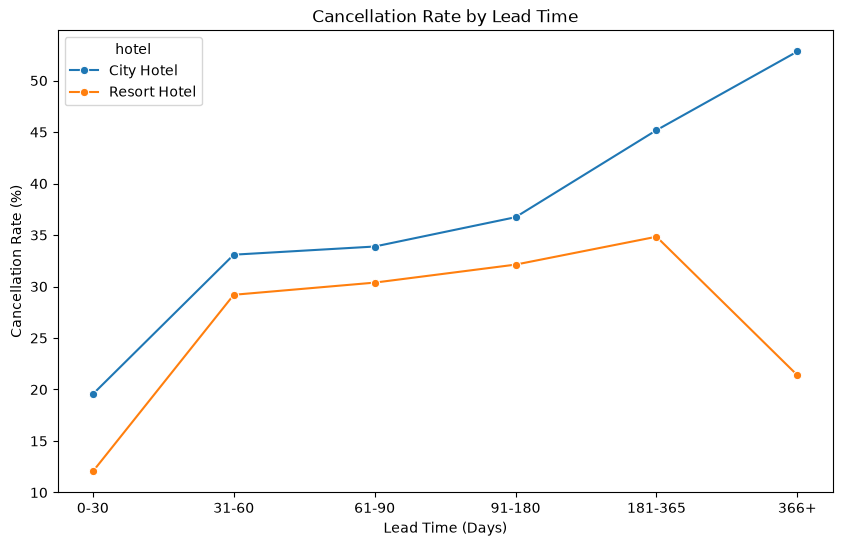

In [24]:
bins = [0, 30, 60, 90, 180, 365, float('inf')]

labels = [
    '0-30',
    '31-60',
    '61-90',
    '91-180',
    '181-365',
    '366+'
]

df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

lead_cancellation = (
    df.groupby(
        ['lead_time_group', 'hotel'],
        observed=True
    )['is_canceled']
    .mean()
    .mul(100)
    .reset_index(name='cancellation_rate')
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=lead_cancellation,
    x='lead_time_group',
    y='cancellation_rate',
    hue='hotel',
    marker='o'
)

plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Cancellation Rate (%)')

plt.show()

### Insight

The chart shows that cancellation behaviour changes with
booking lead time.

City Hotel shows a stronger increase in cancellation as the
lead time becomes longer. This indicates that bookings made
far in advance may have a higher cancellation risk.

The hotel could reduce this risk by using advance-booking
reminders, suitable deposit policies and flexible rescheduling
options.

# 14. Overall Findings

The exploratory data analysis produced the following key findings:

### 1. Hotel Type
City Hotel receives a larger share of bookings than Resort Hotel,
indicating stronger demand for City Hotel.

### 2. Seasonality
Monthly booking volumes vary throughout the year, showing that
hotel demand is influenced by seasonal patterns.

### 3. Cancellation
Cancellation rates differ between the two hotel types, with
City Hotel showing a higher cancellation rate.

### 4. Stay Duration
Cancellation behaviour changes with the length of stay, and
longer stays can have increased cancellation risk.

### 5. Lead Time
Cancellation risk tends to increase for bookings made further
in advance, particularly for City Hotel.

These findings can help the hotel improve demand planning,
cancellation management, pricing and promotional strategies.

# 15. Business Recommendations

Based on the analysis, the following recommendations can be made:

### 1. Focus on City Hotel cancellations
Since City Hotel has a higher cancellation rate, the hotel can
introduce targeted cancellation-management strategies such as
reminders and suitable deposit policies.

### 2. Use seasonal demand for planning
The hotel can adjust staffing, room availability and promotional
campaigns according to high- and low-demand months.

### 3. Manage long-term bookings carefully
Bookings made far in advance can be monitored through reminders,
rescheduling options and appropriate booking conditions.

### 4. Improve Resort Hotel demand
Since Resort Hotel receives fewer bookings, targeted seasonal
packages and promotional campaigns can be used to increase demand.

# 16. Exporting the Cleaned Dataset

The cleaned dataset is saved as a CSV file so that it can be
used later to develop the Streamlit dashboard.

In [25]:
df.to_csv('cleaned_hotel_data.csv', index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
